In [4]:
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date,timedelta
import pyfolio as pf
from datetime import date,timedelta
import pandas as pd
from tqdm import tqdm
import logging
import numpy as np
%matplotlib inline

if '_LOCAL_PATH_LOADED' not in locals():
    %load_ext autoreload
    %autoreload 2
    import os
    import sys
    module_root='C:/Users/orduk/PycharmProjects/backtest'
    module_path = os.path.abspath(module_root) # or the path to your source code
    sys.path.insert(0, module_path)
    print(f'Added {module_root} to PYTHONPATH')
    _LOCAL_PATH_LOADED=True


Added C:/Users/orduk/PycharmProjects/backtest to PYTHONPATH


In [5]:
from utils.utils import cached_df
from market_data.extractalpha.explore import analyze_ea_model
from market_data.extractalpha.datasets import EATM,EACAM,BaseEADataset
from quant.symreturns import SymReturns


In [3]:
stats = []
pbar = tqdm(range(2001,2024))
for year in pbar:
    for model in ['TM','CAM']:
        pbar.set_postfix_str(f'Year {year} Model {model}')
        s = analyze_ea_model(date(year,1,1),date(year,12,31),model, ver=4)
        if s is not None and len(s):
            s['year'] = year
            stats.append(s)
allstats = pd.concat(stats).reset_index().dropna()
allstats.sort_values('date',inplace=True)
allstats.set_index('date',inplace=True)
def renamer (x):
    return x[0] if  x[1] in ['','mean'] else 'count' if x[1]=='len' else 'ERROR'
allstats.columns = allstats.columns.map(renamer)

100%|█████████████████████████████████████████████████████████████| 23/23 [00:00<00:00, 27.09it/s, Year 2023 Model CAM]


In [6]:
allstats.head()

,Score,o2c,o2cdn,o2csn,o2cbn,count,Component,Model,year
date,,,,,,,,,
2001-02-01,1,0.001256,-0.004798,0.001046,-0.005248,111,Reversal_Component,TM,2001
2001-02-01,7,0.003853,-0.002201,0.004064,0.001049,130,Factor_Momentum_Component,TM,2001
2001-02-01,6,0.005219,-0.000835,0.004904,0.001267,137,Factor_Momentum_Component,TM,2001
2001-02-01,5,0.006750,0.000696,0.007730,0.002899,132,Factor_Momentum_Component,TM,2001
2001-02-01,4,0.006068,0.000014,0.006291,-0.001262,112,Factor_Momentum_Component,TM,2001


In [4]:
topq=allstats[(allstats.Component=='TM1') & ( allstats.Score==1) ]
topq.head()

,Score,o2c,o2cdn,o2csn,o2cbn,count,Component,Model,year
date,,,,,,,,,
2001-02-01,1,-0.003541,-0.009595,-0.004914,-0.011410,98.0,TM1,TM,2001
2001-02-02,1,-0.029973,-0.011051,0.026837,0.000941,90.0,TM1,TM,2001
2001-02-05,1,-0.010711,-0.018055,-0.016499,-0.021155,82.0,TM1,TM,2001
2001-02-06,1,0.013103,0.012437,0.011795,0.012144,78.0,TM1,TM,2001
2001-02-07,1,0.004991,0.005214,0.007264,0.005226,92.0,TM1,TM,2001


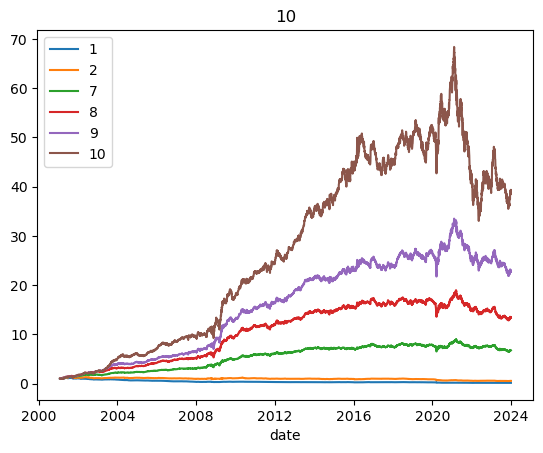

In [5]:
components = allstats.Component.unique().tolist()
#allstats.set_index('date',inplace=True)
quantile = 10
c = 'TM1'
for quantile in [1,2,7,8,9,10]:
    creturns = (1+allstats[(allstats.Component==c) & ( allstats.Score==quantile)]['o2cdn']).cumprod()
    creturns.name= quantile
    creturns.plot(title=quantile,legend=True)


#help(creturns.plot)

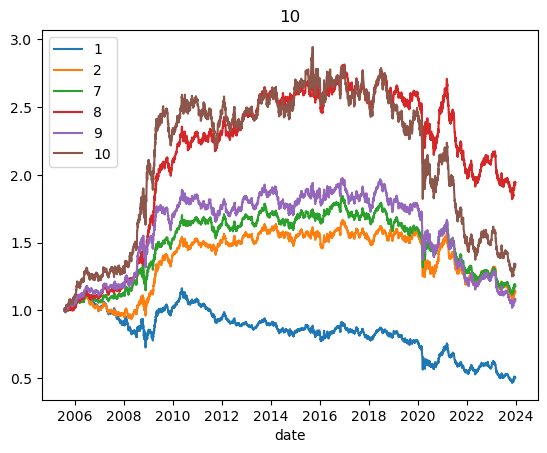

In [11]:
components = allstats.Component.unique().tolist()
#allstats.set_index('date',inplace=True)
quantile = 10
c = 'CAM1'
for quantile in [1,2,7,8,9,10]:
    creturns = (1+allstats[(allstats.Component==c) & ( allstats.Score==quantile)]['o2cbn']).cumprod()
    creturns.name= quantile
    creturns.plot(title=quantile,legend=True)


#help(creturns.plot)

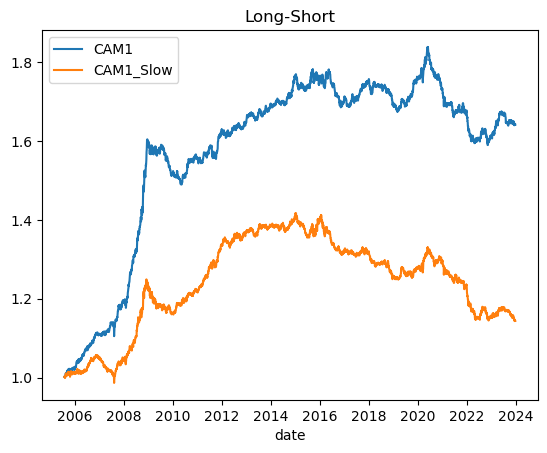

In [9]:
m = 'o2csn'
for c in ['CAM1','CAM1_Slow']:#, 'TM1']:
    lrets = allstats[(allstats.Component==c) & ( allstats.Score==10)][m]
    srets = allstats[(allstats.Component==c) & ( allstats.Score==1)][m]
    drets=(lrets-srets)/2.0
    prets = (1+drets).cumprod()
    prets.name = c
    prets.plot(title=f'Long-Short',legend=True)

In [53]:
drets[drets.index>date(2016,1,1)]

date
2016-01-04    0.006804
2016-01-05   -0.002328
2016-01-06    0.011570
2016-01-07    0.008008
2016-01-08   -0.006032
                ...   
2023-12-22    0.001244
2023-12-26   -0.001470
2023-12-27   -0.002823
2023-12-28    0.003666
2023-12-29   -0.001998
Name: o2csn, Length: 2011, dtype: float32

Start date,2016-01-04
End date,2023-12-29
Total months,95
,Backtest
Annual return,1.957%
Cumulative returns,16.731%
Annual volatility,6.051%
Sharpe ratio,0.35
Calmar ratio,0.12
Stability,0.48
Max drawdown,-16.91%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,16.91,2021-02-05,2022-05-09,NaT,NaN
1,12.34,2016-05-17,2019-08-23,2020-04-07,1016
2,5.18,2020-07-06,2020-09-17,2021-01-28,149
3,2.71,2016-03-07,2016-04-01,2016-05-02,41
4,2.07,2016-02-17,2016-02-26,2016-03-07,14


C:\Users\orduk\anaconda3\envs\aocapital\lib\site-packages\pyfolio\tears.py:1004: UserWarning: Passed returns do not overlap with anyinteresting times.
  warnings.warn(


date
2001-02-01   -0.001051
2001-02-02   -0.004947
2001-02-05    0.008561
2001-02-06    0.001992
2001-02-07   -0.005239
                ...   
2023-12-22    0.001244
2023-12-26   -0.001470
2023-12-27   -0.002823
2023-12-28    0.003666
2023-12-29   -0.001998
Name: o2csn, Length: 5763, dtype: float32

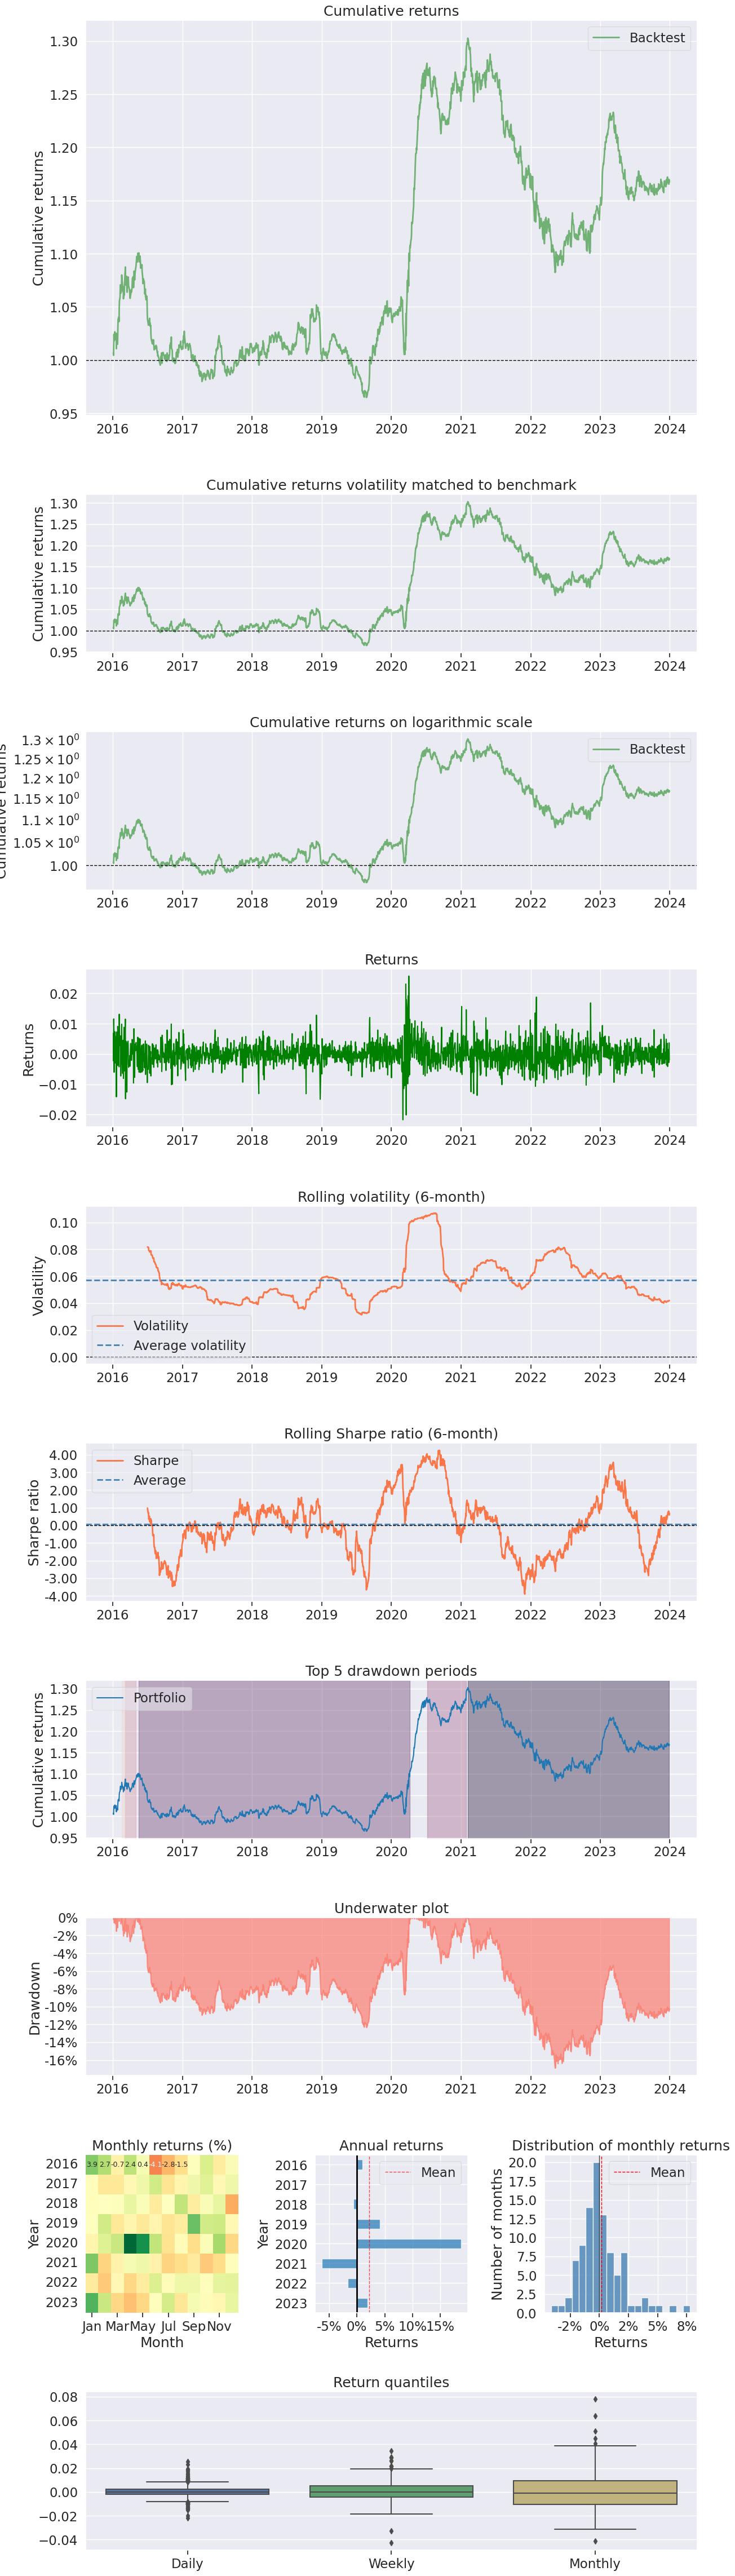

In [54]:
import pyfolio as pf
pyfdrets = drets[drets.index>date(2016,1,1)].copy()
pyfdrets.index = pd.to_datetime(pyfdrets.index)
pf.create_full_tear_sheet(pyfdrets)
drets